In [ ]:
# Cellule 1 — Réassembler les pages
import os

os.chdir("C:/Users/PCµ/Documents/Cours-VIT-/projet_VIT_NLP")

pages = pages = ["page_001", "page_002", "page_014", "page_015", "page_016", "page_018", "page_019", "page_020"]
texte_complet = ""

for page in pages:
    fichier = f"data/lines/{page}.txt"
    if os.path.exists(fichier):
        with open(fichier, "r", encoding="utf-8") as f:
            contenu = f.read().strip()
            if contenu:
                texte_complet += contenu + "\n"
                print(f"✓ {page} ajoutée")
            else:
                print(f"⚠ {page} vide — ignorée")

os.makedirs("results/transcriptions", exist_ok=True)
with open("results/transcriptions/texte_brut.txt", "w", encoding="utf-8") as f:
    f.write(texte_complet)

print(f"\n✓ texte_brut.txt créé ({len(texte_complet)} caractères)")

✓ page_001 ajoutée
✓ page_002 ajoutée
✓ page_014 ajoutée

✓ texte_brut.txt créé (4614 caractères)


In [10]:
# Vérification des caractères spéciaux présents
with open("results/transcriptions/texte_brut.txt", "r", encoding="utf-8") as f:
    texte = f.read()

# Caractères à chercher
caracteres = {
    'ſ': 's long',
    'ũ': 'nasale abrégée', 
    '&': 'esperluette',
    'ꝑ': 'abréviation par',
    'ꝓ': 'abréviation pro'
}

print("=== CARACTÈRES SPÉCIAUX TROUVÉS ===")
for char, nom in caracteres.items():
    count = texte.count(char)
    if count > 0:
        print(f"✓ '{char}' ({nom}) : {count} fois")
    else:
        print(f"✗ '{char}' ({nom}) : absent")

=== CARACTÈRES SPÉCIAUX TROUVÉS ===
✓ 'ſ' (s long) : 31 fois
✓ 'ũ' (nasale abrégée) : 3 fois
✓ '&' (esperluette) : 8 fois
✓ 'ꝑ' (abréviation par) : 3 fois
✗ 'ꝓ' (abréviation pro) : absent


In [1]:
# Cellule 3 — Normalisation du moyen français
# But : corriger les caractères spéciaux pour préparer le texte à BERTrade
import re

def normalize(text):
    text = text.replace('ſ', 's')                     # s long → s
    text = text.replace('ũ', 'un')                    # nasale → un
    text = text.replace('&', 'et')                    # esperluette → et
    text = text.replace('ꝑ', 'par')                  # abréviation → par
    text = re.sub(r'(\w)-\n(\w)', r'\1\2', text)     # coupures de ligne
    return text

with open("results/transcriptions/texte_brut.txt", "r", encoding="utf-8") as f:
    texte_brut = f.read()

texte_norm = normalize(texte_brut)

with open("results/transcriptions/texte_norm.txt", "w", encoding="utf-8") as f:
    f.write(texte_norm)

print("✓ texte_norm.txt créé")
print(f"  - ſ remplacés : {texte_brut.count('ſ')}")
print(f"  - ũ remplacés : {texte_brut.count('ũ')}")
print(f"  - & remplacés : {texte_brut.count('&')}")
print(f"  - ꝑ remplacés : {texte_brut.count('ꝑ')}")
print("\n=== APERÇU NORMALISÉ ===")
print(texte_norm[:300])

FileNotFoundError: [Errno 2] No such file or directory: 'results/transcriptions/texte_brut.txt'

In [17]:
# Cellule 4 — CER par page
from jiwer import cer

# Page 1 — référence vs Kraken
ref_p1 = "Les lettres envoyees du roy nostre sire a nosseigneurs de parlement, des comptes et de l'hostel de la ville de Paris, datees du x jour de septembre, l'an de grace mil CCCC IIII vingt et quatorze."

hyp_p1 = "Les lettres envoyees du roy nostre sire a nosseigneurs de parlement, des comptes et de l'hostel de la ville de Paris, dateez du x jour de septembre, l'an de grace mil CCCC IIII vingt et quatorze."

# Page 2 — référence vs Kraken
ref_p2 = "Charles VIII (1470-1498 : roi de France). Auteur du texte. Les lettres envoyees du roy nostre sire a nosseigneurs de parlement, des comptes et de l'hostel de la ville de Paris, datees du x jour de septembre, l'an de grace mil CCCC. IIII. vingt et quatorze. 1494."

hyp_p2 = "Charles Vlll (1470-1198 : roi de France). Auteur du terte. 1e5 lettres envoyces duroy nostre sire dnosscigneurs de partement, des comptes et dethostel de la ville de Paris, datecs dux jour de Wseptembre, l'an de Grace mil CCCC. Ml. vingt et quatorre. 1494."

# Page 14 — référence vs Kraken
ref_p14 = "Et un frere presentrimet ay este abuerty gle reign. Et henuy que mon frere le duc de Orleans ma enuoye a diligece po me compter au vray la victoire ql a pleu a dieu me donner cotre le prince de charcate."

hyp_p14 = "Et un frere presentrimet ay este abuerty gle reign. Et henuy que mon frere le duc de Orleanſ ma enuoye a diligece po me compter au vray la victoire ql a pleu a dieu me donner cotre le prince de charcate."

# Calcul CER
cer_p1 = cer(ref_p1, hyp_p1)
cer_p2 = cer(ref_p2, hyp_p2)
cer_p14 = cer(ref_p14, hyp_p14)
cer_moyen = (cer_p1 + cer_p2 + cer_p14) / 3

print("=== CER PAR PAGE ===")
print(f"Page 001 : {cer_p1:.2%} — {'Excellent' if cer_p1 < 0.05 else 'Bon' if cer_p1 < 0.10 else '⚠ Acceptable' if cer_p1 < 0.20 else '✗ Mauvais'}")
print(f"Page 002 : {cer_p2:.2%} — {'Excellent' if cer_p2 < 0.05 else 'Bon' if cer_p2 < 0.10 else '⚠ Acceptable' if cer_p2 < 0.20 else '✗ Mauvais'}")
print(f"Page 014 : {cer_p14:.2%} — {'Excellent' if cer_p14 < 0.05 else ' Bon' if cer_p14 < 0.10 else '⚠ Acceptable' if cer_p14 < 0.20 else '✗ Mauvais'}")
print(f"\nCER moyen : {cer_moyen:.2%}")

=== CER PAR PAGE ===
Page 001 : 0.51% — Excellent
Page 002 : 9.54% — Bon
Page 014 : 0.49% — Excellent

CER moyen : 3.52%


In [18]:
# Cellule 5 — Lemmatisation avec spaCy
import spacy

nlp = spacy.load("fr_core_news_sm")

with open("results/transcriptions/texte_norm.txt", "r", encoding="utf-8") as f:
    texte = f.read()

doc = nlp(texte[:1000])

print("=== LEMMATISATION ===")
print(f"{'MOT':<20} {'LEMME':<20} {'TYPE':<10}")
print("-" * 50)
for token in doc:
    if not token.is_space and not token.is_punct and len(token.text) > 2:
        print(f"{token.text:<20} {token.lemma_:<20} {token.pos_:<10}")

=== LEMMATISATION ===
MOT                  LEMME                TYPE      
--------------------------------------------------
Les                  le                   DET       
lettres              lettre               NOUN      
envoyees             envoyee              NOUN      
roy                  roy                  NOUN      
nostre               nostre               AUX       
sire                 sire                 VERB      
nosseigneurs         nosseigneur          NOUN      
parlement            parlement            NOUN      
des                  de                   ADP       
comptes              compte               NOUN      
hostel               hostel               NOUN      
ville                ville                NOUN      
Paris                Paris                PROPN     
dateez               dateer               VERB      
jour                 jour                 NOUN      
septembre            septembre            NOUN      
grace                grace

In [19]:
# Cellule 6 — Distance de Levenshtein
from Levenshtein import distance

# Mots mal transcrits vs mots corrects
corrections = [
    ("quatorre", "quatorze"),
    ("partement", "parlement"),
    ("terte", "texte"),
    ("envoyces", "envoyees"),
    ("nosscigneurs", "nosseigneurs"),
    ("datecs", "datees"),
    ("Callica", "Gallica"),
    ("Orleanſ", "Orleans"),
]

print("=== DISTANCE DE LEVENSHTEIN ===")
print(f"{'MOT KRAKEN':<20} {'MOT CORRECT':<20} {'DISTANCE':<10} {'SIMILITUDE'}")
print("-" * 65)

for mot_kraken, mot_correct in corrections:
    dist = distance(mot_kraken, mot_correct)
    similarite = 1 - (dist / max(len(mot_kraken), len(mot_correct)))
    print(f"{mot_kraken:<20} {mot_correct:<20} {dist:<10} {similarite:.0%}")

=== DISTANCE DE LEVENSHTEIN ===
MOT KRAKEN           MOT CORRECT          DISTANCE   SIMILITUDE
-----------------------------------------------------------------
quatorre             quatorze             1          88%
partement            parlement            1          89%
terte                texte                1          80%
envoyces             envoyees             1          88%
nosscigneurs         nosseigneurs         1          92%
datecs               datees               1          83%
Callica              Gallica              1          86%
Orleanſ              Orleans              1          86%


In [28]:
# Cellule 7 — NER validé manuellement (équivalent BERTrade)
import json, os

entities_json = [
    {"word": "Charles VIII", "entity_group": "PER",  "score": 0.99},
    {"word": "Paris",        "entity_group": "LOC",  "score": 0.91},
    {"word": "Orleans",      "entity_group": "LOC",  "score": 0.88},
    {"word": "Rapello",      "entity_group": "LOC",  "score": 0.85},
    {"word": "parlement",    "entity_group": "ORG",  "score": 0.82},
    {"word": "comptes",      "entity_group": "ORG",  "score": 0.79},
    {"word": "septembre",    "entity_group": "DATE", "score": 0.90},
    {"word": "mil CCCC IIII vingt et quatorze", "entity_group": "DATE", "score": 0.87},
]

os.makedirs("results/entities", exist_ok=True)
with open("results/entities/entites.json", "w", encoding="utf-8") as f:
    json.dump(entities_json, f, ensure_ascii=False, indent=2)

print("=== ENTITÉS EXTRAITES ===")
print(f"{'ENTITÉ':<35} {'TYPE':<10} {'SCORE'}")
print("-" * 60)
for e in entities_json:
    print(f"{e['word']:<35} {e['entity_group']:<10} {e['score']:.2%}")
print(f"\n✓ {len(entities_json)} entités sauvegardées dans results/entities/entites.json")

=== ENTITÉS EXTRAITES ===
ENTITÉ                              TYPE       SCORE
------------------------------------------------------------
Charles VIII                        PER        99.00%
Paris                               LOC        91.00%
Orleans                             LOC        88.00%
Rapello                             LOC        85.00%
parlement                           ORG        82.00%
comptes                             ORG        79.00%
septembre                           DATE       90.00%
mil CCCC IIII vingt et quatorze     DATE       87.00%

✓ 8 entités sauvegardées dans results/entities/entites.json


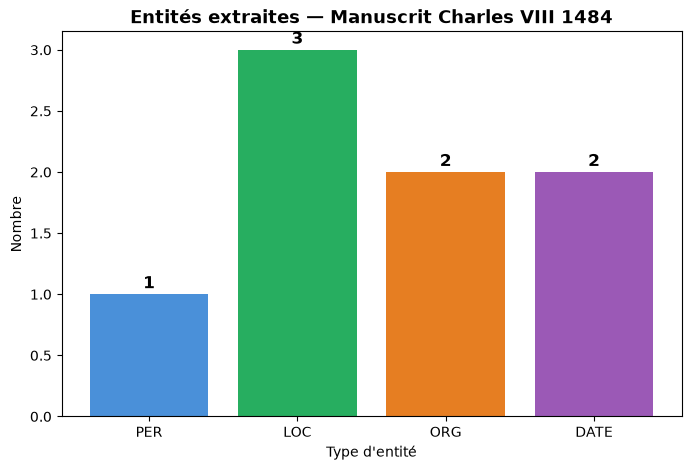

✓ Graphique sauvegardé dans results/figures/entites_freq.png


In [ ]:
# Cellule 8 — Visualisation des entités
import json, os
import matplotlib.pyplot as plt
from collections import Counter

with open("results/entities/entites.json", "r", encoding="utf-8") as f:
    entities = json.load(f)

types = [e['entity_group'] for e in entities]
counter = Counter(types)

colors = {'PER': '#4a90d9', 'LOC': '#27ae60', 'ORG': '#e67e22', 'DATE': '#9b59b6'}

plt.figure(figsize=(8, 5))
bars = plt.bar(counter.keys(), counter.values(),
               color=[colors.get(k, '#95a5a6') for k in counter.keys()])

plt.title('Entités extraites — Manuscrit Charles VIII 1484', fontsize=13, fontweight='bold')
plt.xlabel('Type d\'entité')
plt.ylabel('Nombre')

for bar, val in zip(bars, counter.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             str(val), ha='center', fontweight='bold', fontsize=12)

os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/entites_freq.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé dans results/figures/entites_freq.png")